# バリア関数と内点法について

バリア関数は制約条件を評価関数へ組み込むための手法であり、内点法はバリア項を考慮した評価関数の最適値を数値計算で探すための手法である。

バリア関数は対数を用いて構成されることを示し、それを組み込んだ評価関数は極限でKKT条件と一致すること示す。

内点法は1変数と2変数の例の実際の例を示す。


## 対数の性質

$\log_a(x) = b$ とは $a^b = x$ を満たす指数 $b$ のことである。<br>
例えば低数 $a$ を10とすると、$10^b = x$ ということから、xを正方方向から$0$に近づけていくと、

|$x$|$b$|
|---:|---:|
|100|10|
|10|1|
|0.1|-1|
|0.001|-3|
|0.00001|-5|

のように $-\infty$ に近づいていく。

これは $x \rightarrow 0^+$ のとき $log(x) \rightarrow -\infty$ と表記できる。

実際に図で描くと、正方向から0に近づけていく状況を見ると0付近で急激に下がっている。この図で気を付けることは負方向では logは実数では定義されない。これは制約条件を考えるときに気を付けるべきポイントである。

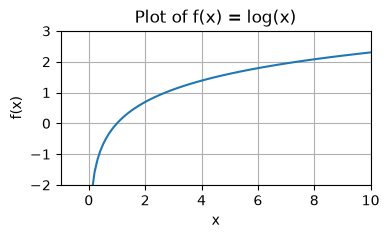

In [3]:
import matplotlib.pyplot as plt
import numpy as np

x = np.linspace(0.00001, 10, 100)
f = np.log(x)

fig, ax = plt.subplots(1,1, figsize=(4,2))
ax.plot(x, f)
ax.set_title('Plot of f(x) = log(x)')
ax.set_xlabel('x')
ax.set_ylabel('f(x)')
ax.set_xlim(-1, 10)
ax.set_ylim(-2, 3)
ax.grid()

## 解きたい問題

次の制約条件 $g(x) \le 0$ を満たす 目的関数 $f(x)$ を最小化する $x$ を求めたいという問題がある。

$$
\min_{x} f(x) \hspace{1em} \text{subject to} \hspace{1em} \space g(x) \le 0
$$

例えば $f(x) = x^2$ , $g(x) = x +1 \le 0$ というものである。この場合、$x=-1$という正解が導かれるが、これがもっと複雑になった場合、数値計算による方法が必要になる。<br>
制約条件を目的関数に組みこむ方法がバリア関数であり、そのバリア付き目的関数を数値的に解くアルゴリズムが内点法である。

## バリア関数

対数$\log(x)$の性質は上記で見た通り、 $x \rightarrow 0^+$ のとき $\log(x) = -\infty$ というものである。また、$x \rightarrow 0^{-}$ と負側から $0$へ近づける場合は $\log(x)$ は実数では定義されない。

制約条件は $g(x) \le 0$ であり 許容領域で負または$0$となる。そのため $\log(g(x))$は実数では定義されない、ということになる。

そこで、$gg(x) = -g(x)$ として、制約条件 $g(x) \le 0$ を $gg(x) \ge 0$ へ書き換える。

また、最小化問題では制約の外側へ進まないように、境界へ近づくほど評価関数が無限大になるような関数を加える。それを対数関数$\log$で実現する。

$\log(gg)$ とすると制約の境界へ近づき、$gg(x) \rightarrow 0^+$ のとき $-\infty$ である。そのため最小化では境界へ積極的に近づく方向に働いてしまう。そこで $-\log(gg)$とすると$gg(x) \rightarrow 0^+$ で $+\infty$ となる。これをバリア関数と呼ぶ。

バリア関数を評価関数$f$に次のように組み込み、

$$
\bar{f}(x) = f(x) - \mu \log(gg(x))
$$

以下の制約なし問題に変換する。

$$
\min_{x} \bar{f}(x)  \hspace{1em}  \xcancel{\text{subject to} \hspace{1em} \space g(x) \le 0}
$$

ただし、$\log(gg)$は $gg > 0$ でのみ定義されるため、探索は常に制約の内側で行われる。



### バリア付き評価関数の停留条件

バリア関数付き評価関数は通常は数値計算によって解くが、その前に停留条件を解析的に導出してみよう。

ラグランジュの未定乗数法で見たように、停留条件を $\bar{f}(x)$ の一次変化がゼロとなる場所を探す。

そうすると、$f(x), gg(x) = - g(x)$ は多変数であるため、偏微分は $\nabla f, \nabla gg = -\nabla g$ となる。<br>
また$\log(x)$ の $x$による偏微分は $1/x$ である。今 $\log(gg(x))$ となっているため、チェインルールより、$\log(gg(x))$の$x$による偏微分は $1/gg(x) \nabla gg$となる。

$$
\nabla \log(gg(x)) = \frac{1}{gg(x)} \nabla gg \
$$

よって停留条件は以下となる。

$$
\nabla \bar{f} = \nabla f - \frac{\mu}{gg(x)} \nabla gg = \nabla f + \frac{\mu}{gg(x)} \nabla g = 0

$$ 

以下のように$\lambda$を設定すると、

$$
\boxed{
\lambda = \frac{\mu}{gg(x)}
}
$$

以下のようになる。これはKKTの停留条件である。

$$
\boxed{
\nabla \bar{f} = \nabla f + \lambda \nabla g = 0
}
$$ 

さらに、

$$
\lambda gg(x) = \mu
$$

で、$\mu \rightarrow 0$なら、以下となり、これはKKTにおける相補性条件である。

$$
\boxed{
\lambda gg(x) = 0
}
$$

制約内部では $gg(x) > 0$ であり、バリア関数の係数 $\mu > 0$ である、したがって

$$
\lambda = \frac{\mu}{gg(x)} > 0
$$

となり、KKT条件の $\lambda \ge 0$ を満たす。


このように、バリア関数による制約を加えた評価関数 $\bar{f}$ は $\mu \rightarrow 0$ の極限でKKT条件と一致する。

## 数値計算による最小化

### ニュートン法

ニュートン法はテイラー展開より導くことが出来る。

テイラー展開の3次以上の項を無視した2次近似の式は以下のようになる。これは1変数の場合で記述している。

$$
f_{II}(x + \Delta x) = f(x) + \frac{d f(x)}{d x} \Delta x + \frac{1}{2} \frac{d^2 f(x)}{d x^2} \Delta x^2
$$

この $f_{II}$ を $\Delta x$ で微分し停留条件を考えると、2次近似の停留点(極大、または極小)を求めることが出来る。

$$
\frac{d f(x)}{d x} + \frac{d^2 f(x)}{d x^2} \Delta x = 0
$$

テイラー展開の展開点を $x_k$ とすると $d f(x) / dx |_{x=x_k} = f'(x_k)$ , $d^2 f(x) / dx^2 |_{x=x_k}= f''(x_k)$は定数になり、$\Delta x$は変数となる。よって、展開点 $x_k$ から2次近似の停留点までの距離(更新量)は次のようになる。

$$
\Delta x = - \frac{f'(x_k)}{f''(x_k)}
$$

よって、これを初期値 $x_k$から繰り返していくと、$|\Delta x| < \varepsilon$ となる場所を極値として求めることが出来る。

処理のイメージは以下のようになる。展開点 $x_k$ におけるテイラー展開の2次近似を $f_{{II} \space k}$ として、$x_k$ から $f_{{II} \space k}$ の停留点までの距離 $\Delta x_k$ を求める。次に、$x_{k+1} = x_k + \Delta x_k$ として、その点の $f_{{II} \space k+1}$ の停留点までの距離 $\Delta x_{k+1}$ を求める、といったように繰り返していく。最終的に極値では $\Delta x_{k+n} \le \varepsilon$ と小さくなる。

<img src="images/newton_method_image.png" style="width:50%;">

多変数の場合、勾配 $\nabla f$ とヘッセ行列 $H$ を用いて、展開点 $x_k$ から2次近似の停留点までの距離(更新量)は次の計算になる。

$$
\Delta \mathbf{x} = - H^{-1}(x_k) \nabla f(x_k)
$$

ここで $H$ は正方行列であるため、LU分解などの直接法を用いて解くことが出来る。

### バリア関数を組み込んだニュートン法

バリア関数を組み込んだ評価関数 $\bar{f}$ のニュートン法を考える。

$$
\bar{f}(x) = f(x) - \mu \log(gg(x))
$$

ニュートン法に必要な1階微分と、2階微分の項は以下となる。

$$
\begin{aligned}
\bar{f}'(x) &= f'(x) - \mu gg^{-1}(x) gg'(x) \\
\bar{f}''(x) &= f''(x) + \mu \frac{(gg'(x))^2}{gg(x)^2}  - \mu \frac{gg''(x)}{gg(x)}  \\
\end{aligned}
$$

ここから、2次近似式の停留点を求める式は下記となる。

$$
f'(x) - \mu \frac{gg'(x)}{gg(x)}  + \left( f''(x) + \mu \frac{(gg'(x))^2}{gg(x)^2}  - \mu \frac{gg''(x)}{gg(x)} \right)\Delta x = 0
$$

よって、ニュートン法の更新量 $\Delta x$ は次の式となる。

$$
\Delta x = -\frac{f'(x) - \mu \dfrac{gg'(x)}{gg(x)} }{ f''(x) + \mu \dfrac{(gg'(x))^2}{gg(x)^2}  - \mu \dfrac{gg''(x)}{gg(x)}}
$$


バリア付き評価関数に対してニュ－トン法を適用すれば、固定した $\mu>0$ に対する停留点を求めることが出来る。<br>
しかし、このニュートン法による更新を繰り返しても、評価関数そのものが変形される。その結果、停留条件 $\nabla \bar{f}$ も変化するため、固定した $\mu$ に対する停留点は、元の制約付き最適化問題の最適解とは一般的に一致しない。<br>
また、$\mu=0$ とするとバリア項が消え、制約を考慮できなくなる。



## 内点法

解析的に $\bar{f}$ の停留条件を導出した結果、

$$
\nabla \bar{f} = \nabla f + \lambda \nabla g = 0
$$ 

および

$$
\lambda gg(x) = \mu
$$

を得た。

ここで、$\mu \rightarrow 0$ とすると $\lambda gg(x) \rightarrow 0$ となり、KKT条件の相補性条件と一致する。<br>

また、停留条件は

$$
\nabla \bar{f} = \nabla f + \lambda \nabla g = 0
$$ 

であるため、$\mu$ を小さくするにつれてバリア関数の影響が徐々に小さくなり、バリア付き評価関数の停留点はもとの制約付き最適化問題の停留点へ近づいていく。

固定した $\mu_k$ に対してニュートン法を収束するまで繰り返し、その収束点を次の $\mu_{k+1} < \mu_k$ に対する初期値として再びニュートン法を実行する。これを内点法と呼ぶ。

$\mu = 0$ とすると $\bar{f}$からバリア項が消えるため、制約を考慮できなくなる。

一方、$\mu \rightarrow 0$ と徐々に０に近づけていくと、バリア項の影響は徐々に小さくなるが、$\mu > 0$ であるため、バリア関数は存在し続ける。その結果、探索は常に制約の内側で行われ、最終的には制約境界上の最適解へ限りなく近づくことが出来る。


## 数値計算例

### 1変数の例

次の問題を内点法で解く

$$
\boxed{
\begin{array}{c}
\min\limits_x f(x) = x^2 \\
\text{subject to} \quad g(x) = 1 - x \le 1
\end{array}
}
$$

制約条件を次のように変換する。

$$
gg(x) = -g(x) = x - 1 \ge 0 , \quad x \ge 0
$$

バリア関数を組み込んだ評価関数 $\bar{f}$ は次となる。

$$
\bar{f} = x^2 - \mu \log(x-1)
$$

ニュートン法の計算に必要な $\bar{f}$ の1階微分と2階微分は次となる。

$$
\bar{f}' = 2x - \frac{\mu}{x-1}
$$

$$
\bar{f}'' = 2 + \frac{\mu}{(x-1)^2}
$$

よって、ニュートン法における $x_k$ における次の更新量 $\Delta x$ は次のようになる。

$$
\Delta x = - \frac{2x - \dfrac{\mu}{x-1}}{2 + \dfrac{\mu}{(x-1)^2}}
$$

内点法は次のように、ある $\mu_k$ で初期値 $x_0$ からニュートン法を実施しそこでの収束点 $x_d$ を求め、次に$mu_{k+1} < mu_k $ として初期値を$x_d$ として ニュートン法を実施し、そこでの収束点 $x_{d+1}$ を求め、といった形で $\mu$ と $x$ の2重ループになっている。<br>
また、$x_0$ は制約の内側から始める必要がある。

アルゴリズムは次のようになる。

--------------------------
```text
mu = 1.0
mu_tol = 1e-4
x0 = 2 # 制約の内側から始める

x = x0
while mu > mu_tol
    x = NewtonMethod(x, mu)
    mu = beta * mu
end while
```
--------------------------

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from pathlib import Path


# ============================================================
# 問題設定
#
#   minimize    f(x) = x^2
#   subject to  x >= 1
#
# g(x)  = 1 - x <= 0
# gg(x) = -g(x) = x - 1 > 0
#
# バリア付き評価関数
#   f_bar(x, mu) = x^2 - mu * log(x - 1)
# ============================================================

def f(x):
    return x**2


def f_bar(x, mu):
    """
    バリア付き評価関数。
    x <= 1 では実数として定義されないため np.nan を返す。
    """
    x_array = np.asarray(x, dtype=float)
    result = np.full_like(x_array, np.nan, dtype=float)

    valid = x_array > 1.0
    result[valid] = (
        x_array[valid] ** 2
        - mu * np.log(x_array[valid] - 1.0)
    )

    if np.isscalar(x):
        return float(result)

    return result


def f_bar_prime(x, mu):
    return 2.0 * x - mu / (x - 1.0)


def f_bar_second(x, mu):
    return 2.0 + mu / (x - 1.0) ** 2


def newton_delta_x(x, mu):
    """
    ニュートン法による距離 Δx。
    """
    return -f_bar_prime(x, mu) / f_bar_second(x, mu)


# ============================================================
# 内点法の計算履歴を作る
# ============================================================

mu_values = [1.0, 0.3, 0.1, 0.03, 0.01, 0.003]
x = 3.0

newton_tolerance = 1e-8
max_newton_iterations = 20

history = []

for mu_index, mu in enumerate(mu_values):
    for iteration in range(max_newton_iterations):
        delta_x = newton_delta_x(x, mu)

        # ニュートン法のステップ幅
        alpha = 1.0

        # 制約 x > 1 を破らないようにする
        while x + alpha * delta_x <= 1.0:
            alpha *= 0.5

        # バリア付き評価関数が小さくなるまで
        # ステップ幅を半分にする
        current_value = f_bar(x, mu)

        while f_bar(x + alpha * delta_x, mu) > current_value:
            alpha *= 0.5

            if alpha < 1e-12:
                break

        x_next = x + alpha * delta_x

        history.append(
            {
                "mu_index": mu_index,
                "mu": mu,
                "iteration": iteration,
                "x": x,
                "x_next": x_next,
                "delta_x": delta_x,
                "alpha": alpha,
            }
        )

        x = x_next

        if abs(alpha * delta_x) < newton_tolerance:
            break


# 最終フレーム
history.append(
    {
        "mu_index": len(mu_values) - 1,
        "mu": mu_values[-1],
        "iteration": 0,
        "x": x,
        "x_next": x,
        "delta_x": 0.0,
        "alpha": 0.0,
    }
)


# ============================================================
# アニメーション作成
# ============================================================

x_plot = np.linspace(1.001, 3.2, 800)

fig, ax = plt.subplots(figsize=(9, 5.5))

# 元の目的関数
original_line, = ax.plot(
    x_plot,
    f(x_plot),
    linestyle="--",
    linewidth=1.5,
    label=r"$f(x)=x^2$",
)

# バリア付き評価関数
barrier_line, = ax.plot(
    [],
    [],
    linewidth=2.0,
    label=r"$\bar{f}(x)=x^2-\mu\log(x-1)$",
)

# 現在位置
current_point, = ax.plot(
    [],
    [],
    marker="o",
    markersize=9,
    linestyle="None",
    label=r"current $x_k$",
)

# 次の位置
next_point, = ax.plot(
    [],
    [],
    marker="x",
    markersize=10,
    markeredgewidth=2,
    linestyle="None",
    label=r"next $x_{k+1}$",
)

# 移動線
move_line, = ax.plot(
    [],
    [],
    linestyle=":",
    linewidth=1.5,
)

# 制約境界
ax.axvline(
    x=1.0,
    linestyle="-.",
    linewidth=1.5,
    label=r"constraint boundary $x=1$",
)

ax.set_xlim(0.8, 3.2)
ax.set_ylim(-1.0, 12.0)
ax.set_xlabel(r"$x$")
ax.set_ylabel("Objective value")
ax.grid(True)
ax.legend(loc="upper left")

title = ax.set_title("")

info_text = ax.text(
    0.98,
    0.95,
    "",
    transform=ax.transAxes,
    ha="right",
    va="top",
)


def update(frame_index):
    state = history[frame_index]

    mu = state["mu"]
    x_current = state["x"]
    x_next = state["x_next"]

    # 現在の μ に対するバリア付き評価関数
    y_barrier = f_bar(x_plot, mu)
    barrier_line.set_data(x_plot, y_barrier)

    y_current = f_bar(x_current, mu)
    y_next = f_bar(x_next, mu)

    current_point.set_data([x_current], [y_current])
    next_point.set_data([x_next], [y_next])

    move_line.set_data(
        [x_current, x_next],
        [y_current, y_next],
    )

    title.set_text(
        rf"Interior-point method: $\mu={mu:.3g}$"
    )

    info_text.set_text(
        "\n".join(
            [
                f"Newton iteration = {state['iteration']}",
                f"x_k = {x_current:.6f}",
                f"x_(k+1) = {x_next:.6f}",
                f"Δx = {state['delta_x']:.6f}",
                f"α = {state['alpha']:.4f}",
            ]
        )
    )

    return (
        barrier_line,
        current_point,
        next_point,
        move_line,
        title,
        info_text,
    )


animation = FuncAnimation(
    fig,
    update,
    frames=len(history),
    interval=900,
    repeat=True,
    blit=False,
)


# ============================================================
# GIFとして保存
# ============================================================

output_dir = Path("images")
output_dir.mkdir(parents=True, exist_ok=True)

output_path = output_dir / "interior_point_method.gif"

writer = PillowWriter(fps=2)

animation.save(
    output_path,
    writer=writer,
    dpi=120,
)

plt.close(fig)

print(f"Saved: {output_path}")

Saved: images/interior_point_method.gif


<img src="images/interior_point_method.gif" style="width:100%;">

### 2変数の例

次の問題を内点法で解く。

$$
\boxed{
\begin{array}{c}
\min\limits_{x,y} f(x,y) = (x-2)^2 + (y-2)^2 \\
\text{subject to} \quad g(x,y) = x + y -2 \le 0
\end{array}
}
$$

制約条件を次のように変換する。

$$
gg(x,y) = - g(x,y) = 2 - x - y \ge 0 , \quad x+y < 2
$$

バリア付き評価関数

$$
\bar{f}(x,y) = (x-2)^2 + (y-2)^2 - \mu \log(2 - x - y)
$$

ニュートン法で必要な勾配 $\nabla f$、 ヘッセ行列 $H$ は次の値である。

$$
\nabla f = 
\begin{bmatrix}
2(x-2) + \dfrac{\mu}{2-x-y} \\
2(y-2) + \dfrac{\mu}{2-x-y}
\end{bmatrix}
$$

$$
H = 
\begin{bmatrix}
2 + \dfrac{\mu}{(2-x-y)^2} & \dfrac{\mu}{(2-x-y)^2} \\
\dfrac{\mu}{(2-x-y)^2} & 2 + \dfrac{\mu}{(2-x-y)^2}
\end{bmatrix}
$$

ニュートン法では、$ H \Delta \mathbf{x} = \nabla f$ から $\Delta \mathbf{x}$ を解き

$$
\begin{bmatrix}
x_{k+1} \\ y_{k+1}
\end{bmatrix} = 
\begin{bmatrix}
x_{k} \\ y_{k}
\end{bmatrix} +
\begin{bmatrix}
\Delta x_{k} \\ \Delta y_{k}
\end{bmatrix} 
$$

として収束点(最適値)を探す。

数値計算では制約を飛び越えることが起きることを防ぐため、ステップは場 $\alpha, \space 0 < \alpha \le 1$ を設ける、次のようにする。

$$
\begin{bmatrix}
x_{k+1} \\ y_{k+1}
\end{bmatrix} = 
\begin{bmatrix}
x_{k} \\ y_{k}
\end{bmatrix} +
\alpha \begin{bmatrix}
\Delta x_{k} \\ \Delta y_{k}
\end{bmatrix} 
$$



In [7]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from pathlib import Path


# ============================================================
# 問題設定
#
# minimize
#     f(x, y) = (x - 2)^2 + (y - 2)^2
#
# subject to
#     g(x, y) = x + y - 2 <= 0
#
# gg(x, y) = -g(x, y) = 2 - x - y > 0
#
# バリア付き評価関数
#     f_bar(x, y, mu)
#       = (x - 2)^2 + (y - 2)^2
#         - mu * log(2 - x - y)
#
# 制約付き最適解
#     (x, y) = (1, 1)
# ============================================================


def f(point):
    """元の目的関数 f(x, y)。"""
    x, y = point
    return (x - 2.0) ** 2 + (y - 2.0) ** 2


def gg(point):
    """gg(x, y) = -g(x, y)。制約内部では gg > 0。"""
    x, y = point
    return 2.0 - x - y


def f_bar(point, mu):
    """バリア付き評価関数。"""
    value_gg = gg(point)

    if value_gg <= 0.0:
        return np.inf

    return f(point) - mu * np.log(value_gg)


def gradient_f_bar(point, mu):
    """
    バリア付き評価関数の勾配。

    grad f_bar =
        [2(x - 2) + mu / (2 - x - y)]
        [2(y - 2) + mu / (2 - x - y)]
    """
    x, y = point
    value_gg = gg(point)

    return np.array(
        [
            2.0 * (x - 2.0) + mu / value_gg,
            2.0 * (y - 2.0) + mu / value_gg,
        ],
        dtype=float,
    )


def hessian_f_bar(point, mu):
    """
    バリア付き評価関数のヘッセ行列。
    """
    value_gg = gg(point)
    barrier_hessian = mu / value_gg**2

    return np.array(
        [
            [2.0 + barrier_hessian, barrier_hessian],
            [barrier_hessian, 2.0 + barrier_hessian],
        ],
        dtype=float,
    )


def newton_direction(point, mu):
    """
    H delta = -grad を解き、ニュートン方向 delta を求める。
    逆行列は明示的に計算しない。
    """
    gradient = gradient_f_bar(point, mu)
    hessian = hessian_f_bar(point, mu)

    return np.linalg.solve(hessian, -gradient)


def backtracking_line_search(
    point,
    delta,
    mu,
    shrink=0.5,
    armijo=1e-4,
    minimum_alpha=1e-12,
):
    """
    制約内部を保ち、かつ評価関数が減少するように
    alpha を小さくするバックトラッキング。
    """
    alpha = 1.0
    current_value = f_bar(point, mu)
    gradient = gradient_f_bar(point, mu)

    while alpha > minimum_alpha:
        next_point = point + alpha * delta

        # 制約内部 gg > 0 を保つ
        if gg(next_point) <= 0.0:
            alpha *= shrink
            continue

        next_value = f_bar(next_point, mu)

        # Armijo条件
        if next_value <= (
            current_value
            + armijo * alpha * np.dot(gradient, delta)
        ):
            return alpha

        alpha *= shrink

    raise RuntimeError(
        "ステップ幅 alpha を決定できませんでした。"
    )


# ============================================================
# 内点法の履歴を計算
# ============================================================

mu_values = [1.0, 0.3, 0.1, 0.03, 0.01, 0.003]

# 制約内部 x + y < 2 から開始
point = np.array([-1.0, 0.0], dtype=float)

newton_tolerance = 1e-8
max_newton_iterations = 30

history = []
mu_solution_points = []

for mu_index, mu in enumerate(mu_values):

    for iteration in range(max_newton_iterations):

        gradient = gradient_f_bar(point, mu)
        delta = newton_direction(point, mu)

        alpha = backtracking_line_search(
            point=point,
            delta=delta,
            mu=mu,
        )

        next_point = point + alpha * delta

        history.append(
            {
                "mu_index": mu_index,
                "mu": mu,
                "iteration": iteration,
                "point": point.copy(),
                "next_point": next_point.copy(),
                "delta": delta.copy(),
                "alpha": alpha,
                "gradient_norm": np.linalg.norm(gradient),
            }
        )

        point = next_point

        # ニュートン法の収束判定
        if np.linalg.norm(alpha * delta) < newton_tolerance:
            break

    mu_solution_points.append(point.copy())


# 最終状態を1フレーム追加
history.append(
    {
        "mu_index": len(mu_values) - 1,
        "mu": mu_values[-1],
        "iteration": 0,
        "point": point.copy(),
        "next_point": point.copy(),
        "delta": np.zeros(2),
        "alpha": 0.0,
        "gradient_norm": np.linalg.norm(
            gradient_f_bar(point, mu_values[-1])
        ),
    }
)


# ============================================================
# 等高線描画用データ
# ============================================================

x_values = np.linspace(-2.0, 2.5, 350)
y_values = np.linspace(-2.0, 2.5, 350)

X, Y = np.meshgrid(x_values, y_values)

Z_original = (X - 2.0) ** 2 + (Y - 2.0) ** 2

constraint_mask = X + Y < 2.0


# ============================================================
# アニメーション作成
# ============================================================

fig, ax = plt.subplots(figsize=(8, 7))

trajectory_points = []

current_point_artist, = ax.plot(
    [],
    [],
    marker="o",
    markersize=9,
    linestyle="None",
    label=r"current point $(x_k,y_k)$",
)

next_point_artist, = ax.plot(
    [],
    [],
    marker="x",
    markersize=10,
    markeredgewidth=2,
    linestyle="None",
    label=r"next point $(x_{k+1},y_{k+1})$",
)

move_line_artist, = ax.plot(
    [],
    [],
    linestyle=":",
    linewidth=1.5,
)

trajectory_artist, = ax.plot(
    [],
    [],
    marker=".",
    linewidth=1.2,
    label="trajectory",
)

central_path_artist, = ax.plot(
    [],
    [],
    marker="s",
    markersize=5,
    linewidth=1.2,
    linestyle="--",
    label=r"solutions for each $\mu$",
)

title = ax.set_title("")

info_text = ax.text(
    0.98,
    0.98,
    "",
    transform=ax.transAxes,
    ha="right",
    va="top",
)

ax.set_xlim(-2.0, 2.5)
ax.set_ylim(-2.0, 2.5)
ax.set_aspect("equal")
ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$y$")
ax.grid(True)

ax.axline(
    (0.0, 2.0),
    (2.0, 0.0),
    linestyle="-.",
    linewidth=1.8,
    label=r"constraint boundary $x+y=2$",
)

# 元の目的関数の等高線
contour_levels = [1, 2, 4, 6, 8, 12, 16, 20]

original_contours = ax.contour(
    X,
    Y,
    Z_original,
    levels=contour_levels,
    linestyles="--",
)

ax.clabel(
    original_contours,
    inline=True,
    fontsize=8,
)

# 制約外領域を薄く表示
ax.contourf(
    X,
    Y,
    ~constraint_mask,
    levels=[0.5, 1.5],
    alpha=0.15,
)

# 制約なし最適解と制約付き最適解
ax.plot(
    2.0,
    2.0,
    marker="*",
    markersize=12,
    linestyle="None",
    label=r"unconstrained optimum $(2,2)$",
)

ax.plot(
    1.0,
    1.0,
    marker="D",
    markersize=7,
    linestyle="None",
    label=r"constrained optimum $(1,1)$",
)

ax.legend(loc="lower left")


def calculate_barrier_surface(mu):
    """
    現在の mu に対応するバリア付き評価関数を
    制約内部だけで計算する。
    """
    GG = 2.0 - X - Y

    Z_barrier = np.full_like(X, np.nan, dtype=float)

    valid = GG > 0.0

    Z_barrier[valid] = (
        (X[valid] - 2.0) ** 2
        + (Y[valid] - 2.0) ** 2
        - mu * np.log(GG[valid])
    )

    return Z_barrier


barrier_contour_set = None


def clear_barrier_contours():
    global barrier_contour_set

    if barrier_contour_set is not None:
        barrier_contour_set.remove()
        barrier_contour_set = None


def update(frame_index):
    global barrier_contour_set

    state = history[frame_index]

    mu = state["mu"]
    point_current = state["point"]
    point_next = state["next_point"]

    clear_barrier_contours()

    Z_barrier = calculate_barrier_surface(mu)

    barrier_contour_set = ax.contour(
        X,
        Y,
        Z_barrier,
        levels=12,
        linewidths=1.0,
    )

    current_point_artist.set_data(
        [point_current[0]],
        [point_current[1]],
    )

    next_point_artist.set_data(
        [point_next[0]],
        [point_next[1]],
    )

    move_line_artist.set_data(
        [point_current[0], point_next[0]],
        [point_current[1], point_next[1]],
    )

    trajectory_array = np.asarray(
        [state_item["point"] for state_item in history[:frame_index + 1]]
    )

    trajectory_artist.set_data(
        trajectory_array[:, 0],
        trajectory_array[:, 1],
    )

    completed_mu_count = state["mu_index"]

    if completed_mu_count > 0:
        central_path = np.asarray(
            mu_solution_points[:completed_mu_count]
        )

        central_path_artist.set_data(
            central_path[:, 0],
            central_path[:, 1],
        )
    else:
        central_path_artist.set_data([], [])

    title.set_text(
        rf"Interior-point method: $\mu={mu:.3g}$"
    )

    info_text.set_text(
        "\n".join(
            [
                f"Newton iteration = {state['iteration']}",
                f"x = {point_current[0]:.6f}",
                f"y = {point_current[1]:.6f}",
                f"alpha = {state['alpha']:.4f}",
                f"||delta|| = {np.linalg.norm(state['delta']):.3e}",
                f"x + y = {point_current.sum():.6f}",
            ]
        )
    )

    return (
        current_point_artist,
        next_point_artist,
        move_line_artist,
        trajectory_artist,
        central_path_artist,
        title,
        info_text,
    )

animation = FuncAnimation(
    fig,
    update,
    frames=len(history),
    interval=900,
    repeat=False,
    blit=False,
)


# ============================================================
# GIFとして保存
# ============================================================

output_dir = Path("images")
output_dir.mkdir(parents=True, exist_ok=True)

output_path = output_dir / "interior_point_method_2d.gif"

writer = PillowWriter(fps=2)

animation.save(
    output_path,
    writer=writer,
    dpi=120,
)

plt.close(fig)

print(f"Saved: {output_path}")

Saved: images/interior_point_method_2d.gif


<img src="images/interior_point_method_2d.gif" style="width:80%;">

破線が元の目的関数 $f(x,y)$ を示し、角フレームで更新される実践は現在の $\mu$ に対する $\bar{f}(x,y)$ を示している。$\bar{f}$ は制約の内側でしか実数が定義されないため、制約の外側では描かれていない。



## C/GMRESへのつながり

内点法ではニュートン法によって更新量を求める。今回の2変数のように、実際にはヘッセ行列 $H$ と勾配 $\nabla f$ から構成される線形方式

$$
H \Delta x = \nabla f
$$

を解く必要がある。

問題の規模が小さい場合、LU分解などの直接法でも十分な計算時間であるが、モデル予測制御(MPC)では未知数が非常に多くなるため、直接法では計算時間が大きくなり、制御周期に影響が出る。

そこで、大規模な線形方程式を効率よく解く反復法であるGMRESを用いる。

さらに、制御では時刻ごとの最適解は連続的に変化するため、前時刻の解を初期値として利用できる。この性質を利用してリアルタイム最適制御を実現する方法がC/GMRESである。

以上